 2D Navier–Stokes (vorticity form) — quick IC evolution & diagnostics

This notebook does:

1. Load an initial vorticity field `w(x,y)` from a NetCDF file (variable name: `w`).
2. Run a short spectral JAX-CFD integration, plot a couple sanity checks, and save the final vorticity back to NetCDF.

In [2]:
# ----------------------------
# Imports & configuration
# ----------------------------
from __future__ import annotations

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import jax_cfd.base as cfd
import jax_cfd.base.grids as grids
import jax_cfd.spectral as spectral

jax.config.update("jax_enable_x64", True)

In [5]:
# ----------------------------
# User knobs
# ----------------------------
# Input: NetCDF containing vorticity variable `w` on a periodic 2pi box
INP = Path("...\IC.nc") 

# Simulation
TOTAL_TIME = 10.0          # total simulated time
SAVE_EVERY = 0.25          # save cadence (in simulation time units)

# Physics
NU = 1e-6                  # kinematic viscosity
DRAG = 0.0                 # linear drag coefficient (if supported by your JAX-CFD version)
SMOOTH = True              # spectral dealiasing / smoothing toggle (JAX-CFD)
CFL = 0.3                 # CFL used for dt estimate (advection)

# Optional forcing (if supported by your JAX-CFD version)
USE_FORCING = False
KF = 32.0                  # forcing wavenumber (example)
AMP = 0.125                # forcing amplitude (example)

# Output: Where to save
OUT_DIR = Path("...\out.nc")
OUT_DIR.mkdir(parents=True, exist_ok=True)

Loaded w0 with shape (Ny, Nx) = (8192, 8192)


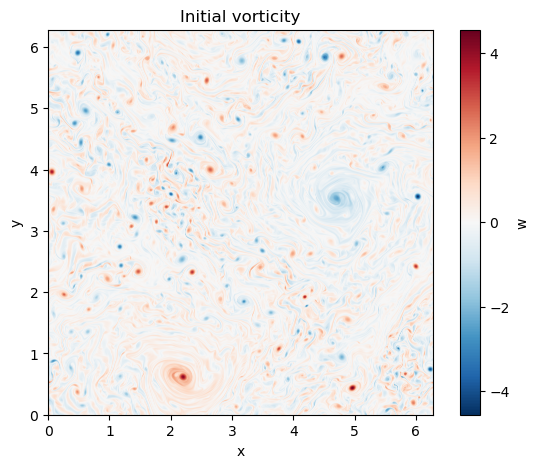

In [10]:
# ----------------------------
# Load initial vorticity
# ----------------------------
ds = xr.open_dataset(INP)
if "w" not in ds:
    raise KeyError(f"Expected variable 'w' in {INP}, found: {list(ds.data_vars)}")

w0 = jnp.asarray(ds["w"].values)
if w0_np.ndim != 2:
    raise ValueError(f"Expected 2D vorticity field, got shape {w0_np.shape}")

Ny, Nx = w0.shape
print(f"Loaded w0 with shape (Ny, Nx) = {w0_np.shape}")

# Quick look
plt.figure(figsize=(7, 5))
vmax = np.max(np.abs(w0))
plt.imshow(w0_np, origin="lower", cmap="RdBu_r",extent=[0, 2*np.pi, 0, 2*np.pi], vmin=-vmax, vmax=vmax)
plt.colorbar(label="w")
plt.title("Initial vorticity")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [30]:
# ----------------------------
# JAX-CFD grid + stable dt estimate
# ----------------------------
grid = grids.Grid((Nx, Ny), domain=((0.0, 2*jnp.pi), (0.0, 2*jnp.pi)))

w_to_v_dns = spectral.utils.vorticity_to_velocity(grid)
w0_hat = jnp.fft.rfft2(w0, axes=(0, 1))                  
u = jnp.fft.irfft2(jnp.stack(w_to_v_dns(w0_hat), axis=-1) , axes=(0, 1))  

max_velocity = jnp.max(jnp.sqrt(u[0]**2+u[1]**2))
print(f"max |u| from w0 (FFT streamfunction) = {max_velocity}")

dt = cfd.equations.stable_time_step(max_velocity, CFL, NU, grid)
print(f"dt_stable = {float(dt)}")

max |u| from w0 (FFT streamfunction) = 0.17431546959116195
dt_stable = 0.001892005742054545


In [ ]:
# ----------------------------
# Build model + integrate (spectral, vorticity in rfft space)
# with integer inner/outer steps and dt tuned so dt*inner_steps == SAVE_EVERY
# ----------------------------

# forcing factory
forcing_fn = None
if USE_FORCING:
    forcing_fn = lambda g: spectral.forcings.checkerboard_forcing_module(g, freq=KF, amp=AMP)

# ---- choose integer stepping ----
dt_est = float(dt)  
inner_steps = int(np.ceil(SAVE_EVERY / dt_est))
inner_steps = max(inner_steps, 1)
dt = SAVE_EVERY / inner_steps  
dt = float(dt)

# Choose outer_steps so you save about TOTAL_TIME / SAVE_EVERY frames
outer_steps = int(np.round(TOTAL_TIME / SAVE_EVERY))
outer_steps = max(outer_steps, 1)

t_final = outer_steps * SAVE_EVERY
if abs(t_final - TOTAL_TIME) > 1e-12:
    print(f"[Note] TOTAL_TIME={TOTAL_TIME} is not an integer multiple of SAVE_EVERY={SAVE_EVERY}.")
    print(f"       Will run to t_final={t_final} (outer_steps={outer_steps}).")

print(f"dt_est={dt_est:.6e}  -> inner_steps={inner_steps}, dt={dt:.6e} (dt*inner_steps={dt*inner_steps:.6e})")
print(f"outer_steps={outer_steps}, saved frames={outer_steps+1}, final saved time={t_final:.6e}")

# ---- build model ----
model = spectral.equations.NavierStokes2D(NU, grid,smooth=SMOOTH,drag=DRAG,forcing_fn=forcing_fn,)

# ---- trajectory ----
step_fn = spectral.time_stepping.crank_nicolson_rk4(model, dt)

# trajectory returns (t, states) in some forks, and just states in others.
# We'll handle both safely.
trajectory_fn = cfd.funcutils.trajectory(cfd.funcutils.repeated(step_fn, inner_steps),outer_steps)

_, traj_out = trajectory_fn(w0_hat)

dt_est=1.892006e-03  -> inner_steps=133, dt=1.879699e-03 (dt*inner_steps=2.500000e-01)
outer_steps=40, saved frames=41, final saved time=1.000000e+01


In [ ]:
# ------------------------------------------------------------
# SAVE: real-space trajectory w(time,y,x) 
# ------------------------------------------------------------

# Ensure OUT_DIR exists
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Convert spectral trajectory -> real trajectory
w_traj = jnp.fft.irfftn(traj_out, axes=(1, 2), s=(Ny, Nx))
w_traj_np = np.asarray(w_traj, dtype=np.float32)

# Time array
t_np = np.asarray(t_saved, dtype=np.float64)

# Coordinates for periodic 2π box
x = np.linspace(0.0, 2*np.pi, Nx, endpoint=False)
y = np.linspace(0.0, 2*np.pi, Ny, endpoint=False)

forcing_name = "checkerboard" if USE_FORCING else "none"

# ONLY attrs from your knobs
attrs = {
    "total_time": float(TOTAL_TIME),
    "save_every": float(SAVE_EVERY),
    "nu": float(NU),
    "drag": float(DRAG),
    "smooth": bool(SMOOTH),
    "cfl": float(CFL),
    "use_forcing": bool(USE_FORCING),
    "forcing": forcing_name,  
    "kf": float(KF),
    "amp": float(AMP),
}

ds_out = xr.Dataset(
    data_vars={"w": (("time", "y", "x"), w_traj_np)},
    coords={"time": t_np, "x": x, "y": y},
    attrs=attrs,
)

# Output filename
stem = Path(INP).stem
out_path = OUT_DIR / f"{stem}_traj_T{TOTAL_TIME:g}_se{SAVE_EVERY:g}.nc"

# Compression
encoding = {"w": {"zlib": True, "complevel": 4, "dtype": "float32"}}

ds_out.to_netcdf(out_path, encoding=encoding)
print("Saved:", out_path)
print("w shape:", w_traj_np.shape, "frames:", len(t_np))